In [24]:
import copy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import sage.all as sage
from sage.all import var, sin, cos, pi, ln, diff

*TODOs:* 
* add better customizability (show/hide init condition points and poincare intersections)
* Add option for center to be actual center or only positive (use all axis or just positive nums)
* Fix plane so it looks normal past boundary
* Create graph of fixed points (color coded based on stability) on poincare plots
* Use better fixed point approximations
* Add animation of moving poincare section
* Make possible poincare sections not just planes
    * Cylinder
    * Sphere (Mercador Projection?)
    * Multiple planes
    * Torus
* 3D Poincare plot
* Upload to git and create file structure

In [25]:
step = 0.025  # precision

tmin, tmax = -10, 20  # t bounds
xmin, xmax = -10, 10  # x bounds
ymin, ymax = -10, 10  # y bounds

specific_solution = [] # to add specific solutions
ic_center = (0.1, 1.0, 0.0) # specify center or set to None for auto
ic_const = 1.0  # size of IC box
point_size = 0.1  # size of inition condition points and Poincaré points
num_st = 1  # number of solution curves on t-axis
num_sx = 7  # number of solution curves on x-axis
num_sy = 7  # number of solution curves on y-axis

show_vectors = False  # show vectorfield ontop of solution curves
show_poincare_section = True  # display Poincaré section plane in 3D plot

# Poincaré section: specify a plane equation a*t + b*x + c*y + d = 0
poincare_a, poincare_b, poincare_c, poincare_d = 1, 0, 0, -5
flip_y = False # y orientation
flip_x = True # x orientation
eps = step  # tolerance for plane intersection + poincare analysis

In [26]:
##### PREDATOR PREY MODEL #####

# # f_x: R x R x R -> R
# # dx/dt = f_x(t, x, y)
# def f_x(t, x, y):
#     growth_rate = 1.0
#     predation_rate = 0.2
#     death_rate = 0.2 
#     return growth_rate * x - predation_rate * x * y - death_rate * x 


# # g_y: R x R x R -> R
# # dy/dt = g_y(t, x, y)
# def g_y(t, x, y):
#     predator_efficiency = 0.2
#     death_rate = 0.4
#     return predator_efficiency * x * y - death_rate * y

In [27]:
##### HOPF BIFURCATION MODEL #####

# mu = -2.0
# alpha = 1.0
# beta = 0.3
# omega = 4.0

# # f_x: R x R x R -> R
# # dx/dt = f_x(t, x, y)
# def f_x(t, x, y):
#     return -mu*x*cos(x) - omega*y + alpha*x*(x**2 + y**2) - beta*x*(x**2 + y**2)**2/t


# # g_y: R x R x R -> R
# # dy/dt = g_y(t, x, y)
# def g_y(t, x, y):
#     return omega*x - mu*y*sin(y) + alpha*y*(x**2 + y**2) - beta*y*(x**2 + y**2)**2/t

In [28]:
##### DYNAMICS FINAL #####


# f_x: R x R x R -> R
# dx/dt = f_x(t, x, y)
def f_x(t, x, y):
    return y


# g_y: R x R x R -> R
# dy/dt = g_y(t, x, y)
def g_y(t, x, y):
    n = 1
    return -(2 / (t + 0.001)) * y - x ** n

In [29]:
##### TEST #####


# # f_x: R x R x R -> R
# # dx/dt = f_x(t, x, y)
# def f_x(t, x, y):
#     return x * sin(y)


# # g_y: R x R x R -> R
# # dy/dt = g_y(t, x, y)
# def g_y(t, x, y):
#     return -y * cos(x)

In [30]:
# padding
pad_t, pad_x, pad_y = ((tmax - tmin) * 0.5, (xmax - xmin) * 0.5, (ymax - ymin) * 0.5)

# initial conditions
if ic_center is None:
    ics = [
        [sage.SR(i * ic_const), sage.SR(j * ic_const), sage.SR(k * ic_const)]
        for i in np.linspace(tmin, tmax + pad_t, num_st)
        for j in np.linspace(xmin, xmax + pad_x, num_sx)
        for k in np.linspace(ymin, ymax + pad_y, num_sy)
    ]
else:
    t_mid = ic_const * (abs(tmax) + abs(tmin)) / 2.0
    x_mid = ic_const * (abs(xmax) + abs(xmin)) / 2.0
    y_mid = ic_const * (abs(ymax) + abs(ymin)) / 2.0
    ics = [
        [sage.SR(i), sage.SR(j), sage.SR(k)]
        for i in np.linspace(
            ic_center[0] - t_mid if num_st != 1 else ic_center[0],
            ic_center[0] + t_mid,
            num_st,
        )
        for j in np.linspace(
            ic_center[1] - x_mid if num_sx != 1 else ic_center[1],
            ic_center[1] + x_mid,
            num_sx,
        )
        for k in np.linspace(
            ic_center[2] - y_mid if num_sy != 1 else ic_center[2],
            ic_center[2] + y_mid,
            num_sy,
        )
    ]
    
ics += [
    [
        sage.SR(specific_solution[i][0]),
        sage.SR(specific_solution[i][1]),
        sage.SR(specific_solution[i][2]),
    ]
    for i in range(len(specific_solution))
]

# initial condition points (to be graphed)
colors = cm.get_cmap("viridis")(np.linspace(0, 1, len(ics)))
ic_points = sum(
    [
        sage.point(
            [ics[i]],
            size=point_size * np.mean([(tmax - tmin), (xmax - xmin), (ymax - ymin)]),
            alpha=1,
            color=mcolors.to_hex(colors[i]),
            faceted=True,
            markeredgecolor="black",
        )
        for i in range(len(ics))
    ]
)

/var/folders/3j/5z92g6nn29n86z0mwbtybwc00000gn/T/ipykernel_11260/1209319987.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("viridis")(np.linspace(0, 1, len(ics)))


In [31]:
# Ensure solutions don't leave the boundary set
def clip_trajectory_to_boundary(trajectory, tmin, tmax, xmin, xmax, ymin, ymax):
    clipped = []
    for point in trajectory:
        t_val, x_val, y_val = float(point[0]), float(point[1]), float(point[2])
        if (
            tmin - pad_t < t_val <= tmax + pad_t
            and xmin - pad_x < x_val <= xmax + pad_x
            and ymin - pad_y < y_val <= ymax + pad_y
        ):
            clipped.append(point)
    return clipped


# Scale vectors in the vector field
def scaled_vector(t_val, x_val, y_val):
    vt, vx, vy = 1, f_x(t_val, x_val, y_val), g_y(t_val, x_val, y_val)
    mag_total = np.sqrt(vt**2 + vx**2 + vy**2)
    mag_h = np.sqrt(vx**2 + vy**2 + vt**2)
    if mag_total == 0:
        return (0, 0, 0)
    min_len, max_len, alpha = 1, 5, 0.2
    s = 1 - np.exp(-alpha * mag_h * step)
    length = min_len + s * (max_len - min_len)
    return (vt / mag_total * length, vx / mag_total * length, vy / mag_total * length)

In [32]:
t, x, y = var("t x y")

solutions, trajectory_vectors  = [], []
for idx, i in enumerate(ics):
    trajectory = sage.desolve_system_rk4(
        [f_x(t, x, y), g_y(t, x, y)],
        vars=[x, y],
        ivar=t,
        ics=i,
        end_points=[tmin, tmax + pad_t],
        step=step,
    )
    clipped = clip_trajectory_to_boundary(
        trajectory, tmin, tmax, xmin, xmax, ymin, ymax
    )

    if len(clipped) >= 2:
        solutions.append(
            sage.list_plot(
                clipped,
                plotjoined=True,
                color=mcolors.to_hex(colors[idx]),
                thickness=1.5,
                # size=4 * np.mean([(tmax - tmin), (xmax - xmin), (ymax - ymin)]),
                # alpha=0.8,
                # faceted=True,
            )
        )
        trajectory_vectors.append((clipped, idx))

    print(f"Completed trajectory {idx + 1} of {len(ics)}")

Completed trajectory 1 of 49
Completed trajectory 2 of 49
Completed trajectory 3 of 49
Completed trajectory 4 of 49
Completed trajectory 5 of 49
Completed trajectory 6 of 49
Completed trajectory 7 of 49
Completed trajectory 8 of 49
Completed trajectory 9 of 49
Completed trajectory 10 of 49
Completed trajectory 11 of 49
Completed trajectory 12 of 49
Completed trajectory 13 of 49
Completed trajectory 14 of 49
Completed trajectory 15 of 49
Completed trajectory 16 of 49
Completed trajectory 17 of 49
Completed trajectory 18 of 49
Completed trajectory 19 of 49
Completed trajectory 20 of 49
Completed trajectory 21 of 49
Completed trajectory 22 of 49
Completed trajectory 23 of 49
Completed trajectory 24 of 49
Completed trajectory 25 of 49
Completed trajectory 26 of 49
Completed trajectory 27 of 49
Completed trajectory 28 of 49
Completed trajectory 29 of 49
Completed trajectory 30 of 49
Completed trajectory 31 of 49
Completed trajectory 32 of 49
Completed trajectory 33 of 49
Completed trajector

In [33]:
poincare_points_3d_up = []
poincare_points_3d_down = []
for traj, traj_idx in trajectory_vectors:
    for idx in range(len(traj) - 1):
        p1 = traj[idx]
        p2 = traj[idx + 1]
        t1, x1, y1 = float(p1[0]), float(p1[1]), float(p1[2])
        t2, x2, y2 = float(p2[0]), float(p2[1]), float(p2[2])
        h1 = poincare_a * t1 + poincare_b * x1 + poincare_c * y1 + poincare_d
        h2 = poincare_a * t2 + poincare_b * x2 + poincare_c * y2 + poincare_d
        if h1 * h2 < 0:
            alpha = -h1 / (h2 - h1)
            t_intersect = t1 + alpha * (t2 - t1)
            x_intersect = x1 + alpha * (x2 - x1)
            y_intersect = y1 + alpha * (y2 - y1)
            if h1 < -eps and h2 > eps:
                poincare_points_3d_up.append((t_intersect, x_intersect, y_intersect, traj_idx))
        elif abs(h1) <= eps:
            if idx > 0:
                if h2 > eps:
                    poincare_points_3d_up.append((t1, x1, y1, traj_idx))
                if h2 < -eps:
                    poincare_points_3d_down.append((t1, x1, y1, traj_idx))

print(
    f"Found {len(poincare_points_3d_up)} points on Poincaré section ('upward' crossings)"
)
print(
    f"Found {len(poincare_points_3d_down)} points on Poincaré section ('downward' crossings)"
)
print(
    f"\nPlane equation: {poincare_a}*t + {poincare_b}*x + {poincare_c}*y + {poincare_d} = 0"
)

Found 49 points on Poincaré section ('upward' crossings)
Found 0 points on Poincaré section ('downward' crossings)

Plane equation: 1*t + 0*x + 0*y + -5 = 0


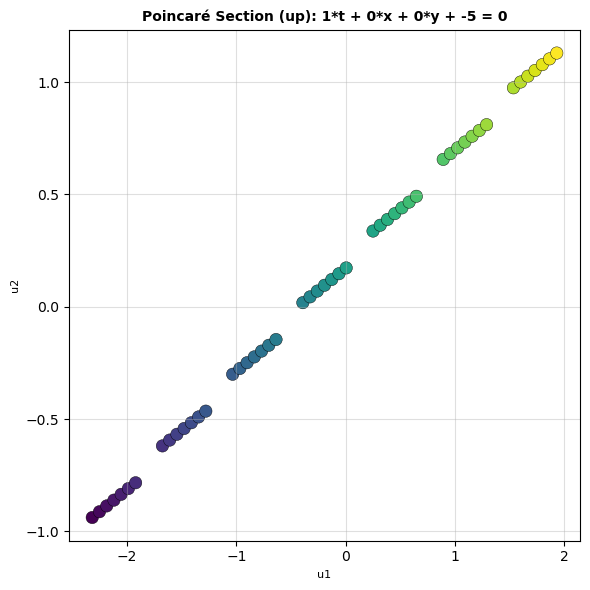

Plane normal vector: [1. 0. 0.]
Plane basis u1: [0. 1. 0.]
Plane basis u2: [0. 0. 1.]


In [34]:
if len(poincare_points_3d_up) > 0:
    normal = np.array([poincare_a, poincare_b, poincare_c], dtype=float)
    normal = normal / np.linalg.norm(normal)
    if abs(normal[0]) < 0.9:
        v1 = np.array([1, 0, 0], dtype=float)
    else:
        v1 = np.array([0, 1, 0], dtype=float)

    u1 = v1 - np.dot(v1, normal) * normal
    u1 = u1 / np.linalg.norm(u1)
    u2 = np.cross(normal, u1)
    u2 = u2 / np.linalg.norm(u2)

    plane_2d_coords = []
    for t_val, x_val, y_val, idx in poincare_points_3d_up:
        point_3d = np.array([t_val, x_val, y_val])
        if abs(poincare_a) > 1e-10:
            ref_point = np.array([-poincare_d / poincare_a, 0, 0])
        elif abs(poincare_b) > 1e-10:
            ref_point = np.array([0, -poincare_d / poincare_b, 0])
        else:
            ref_point = np.array([0, 0, -poincare_d / poincare_c])
        vec_on_plane = point_3d - ref_point
        plane_2d_coords.append((np.dot(vec_on_plane, u1), np.dot(vec_on_plane, u2), idx))

    poincare_plot = plt.figure(figsize=(6, 6))
    u1_coords = [p[0]for p in (plane_2d_coords if not flip_x else reversed(copy.copy(plane_2d_coords)))]
    u2_coords = [p[1] for p in (plane_2d_coords if not flip_y else reversed(copy.copy(plane_2d_coords)))]
    color_idx = np.array([p[2] for p in plane_2d_coords])
    plt.scatter(
        u1_coords,
        u2_coords,
        s=80,
        alpha=1.0,
        c=colors[color_idx],
        edgecolors="black",
        linewidth=0.3,
    )
    plt.xlabel("u1", fontsize=8)
    plt.ylabel("u2", fontsize=8)
    plane_eq = (
        f"{poincare_a}*t + {poincare_b}*x + {poincare_c}*y + {poincare_d} = 0"
        if (poincare_a != 0 or poincare_b != 0 or poincare_c != 0)
        else "Poincaré Section"
    )
    plt.title(f"Poincaré Section (up): {plane_eq}", fontsize=10, fontweight="bold")
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.savefig("./Plots/2D/poincare_plot_up.svg")
    plt.show()

    print(f"Plane normal vector: {normal}")
    print(f"Plane basis u1: {u1}")
    print(f"Plane basis u2: {u2}")
else:
    print("No points found on Poincaré section.")

In [35]:
if len(poincare_points_3d_down) > 0:
    normal = np.array([poincare_a, poincare_b, poincare_c], dtype=float)
    normal = normal / np.linalg.norm(normal)
    if abs(normal[0]) < 0.9:
        v1 = np.array([1, 0, 0], dtype=float)
    else:
        v1 = np.array([0, 1, 0], dtype=float)

    u1 = v1 - np.dot(v1, normal) * normal
    u1 = u1 / np.linalg.norm(u1)
    u2 = np.cross(normal, u1) # flip sign to change orientation
    u2 = u2 / np.linalg.norm(u2)

    plane_2d_coords = []
    for t_val, x_val, y_val, idx in poincare_points_3d_down:
        point_3d = np.array([t_val, x_val, y_val])
        if abs(poincare_a) > 1e-10:
            ref_point = np.array([-poincare_d / poincare_a, 0, 0])
        elif abs(poincare_b) > 1e-10:
            ref_point = np.array([0, -poincare_d / poincare_b, 0])
        else:
            ref_point = np.array([0, 0, -poincare_d / poincare_c])
        vec_on_plane = point_3d - ref_point
        plane_2d_coords.append((np.dot(vec_on_plane, u1), np.dot(vec_on_plane, u2), idx))

    poincare_plot = plt.figure(figsize=(6, 6))
    u1_coords = [p[0] for p in plane_2d_coords]
    u2_coords = [p[1] for p in plane_2d_coords]
    color_idx = np.array([p[2] for p in plane_2d_coords])
    plt.scatter(
        u1_coords,
        u2_coords,
        s=80,
        alpha=1.0,
        c=colors[color_idx],
        edgecolors="black",
        linewidth=0.3,
    )
    plt.xlabel("u1", fontsize=8)
    plt.ylabel("u2", fontsize=8)
    plane_eq = (
        f"{poincare_a}*t + {poincare_b}*x + {poincare_c}*y + {poincare_d} = 0"
        if (poincare_a != 0 or poincare_b != 0 or poincare_c != 0)
        else "Poincaré Section"
    )
    plt.title(f"Poincaré Section (up): {plane_eq}", fontsize=10, fontweight="bold")
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.savefig("./Plots/2D/poincare_plot_up.svg")
    plt.show()

    print(f"Plane normal vector: {normal}")
    print(f"Plane basis u1: {u1}")
    print(f"Plane basis u2: {u2}")
else:
    print("No points found on Poincaré section.")

No points found on Poincaré section.


In [ ]:
def numerical_jacobian(t, x, y, h=1e-5):
    df_dx = (f_x(t, x + h, y) - f_x(t, x - h, y)) / (2 * h)
    df_dy = (f_x(t, x, y + h) - f_x(t, x, y - h)) / (2 * h)
    dg_dx = (g_y(t, x + h, y) - g_y(t, x - h, y)) / (2 * h)
    dg_dy = (g_y(t, x, y + h) - g_y(t, x, y - h)) / (2 * h)

    return np.array([[df_dx, df_dy], [dg_dx, dg_dy]])


poincare_points_3d = poincare_points_3d_down + poincare_points_3d_up
if len(poincare_points_3d) > 0:
    output_filename = "./Data/poincare_analysis.txt"
    with open(output_filename, "w") as file_output:
        file_output.write("=" * 80 + "\n")
        file_output.write("POINCARÉ SECTION ANALYSIS\n")
        file_output.write("=" * 80 + "\n\n")

        file_output.write("SYSTEM PARAMETERS:\n")
        file_output.write(f"  Time bounds: t ∈ [{tmin}, {tmax}]\n")
        file_output.write(
            f"  State space: x ∈ [{xmin}, {xmax}], y ∈ [{ymin}, {ymax}]\n"
        )
        file_output.write(f"  Number of trajectories: {len(trajectory_vectors)}\n")
        file_output.write(f"  Step size: {step}\n\n")

        file_output.write("POINCARÉ SECTION:\n")
        file_output.write(
            f"  Plane equation: {poincare_a}*t + {poincare_b}*x + {poincare_c}*y + {poincare_d} = 0\n"
        )
        file_output.write(f"  epsilon: {eps}\n")
        file_output.write(
            f"  Number of intersection points: {len(poincare_points_3d)}\n\n"
        )

        file_output.write("SECTION POINT STATISTICS:\n")

        t_coords = np.array([p[0] for p in poincare_points_3d])
        x_coords = np.array([p[1] for p in poincare_points_3d])
        y_coords = np.array([p[2] for p in poincare_points_3d])

        file_output.write("  T-coordinate:\n")
        file_output.write(f"    Mean: {t_coords.mean():.6f}\n")
        file_output.write(f"    Std Dev: {t_coords.std():.6f}\n")
        file_output.write(
            f"    Range: [{t_coords.min():.6f}, {t_coords.max():.6f}]\n\n"
        )

        file_output.write("  X-coordinate:\n")
        file_output.write(f"    Mean: {x_coords.mean():.6f}\n")
        file_output.write(f"    Std Dev: {x_coords.std():.6f}\n")
        file_output.write(
            f"    Range: [{x_coords.min():.6f}, {x_coords.max():.6f}]\n\n"
        )

        file_output.write("  Y-coordinate:\n")
        file_output.write(f"    Mean: {y_coords.mean():.6f}\n")
        file_output.write(f"    Std Dev: {y_coords.std():.6f}\n")
        file_output.write(
            f"    Range: [{y_coords.min():.6f}, {y_coords.max():.6f}]\n\n"
        )

        if len(poincare_points_3d) > 1:
            distances = []
            for i in range(len(poincare_points_3d)):
                for j in range(i + 1, len(poincare_points_3d)):
                    dist = np.sqrt(
                        (t_coords[i] - t_coords[j]) ** 2
                        + (x_coords[i] - x_coords[j]) ** 2
                        + (y_coords[i] - y_coords[j]) ** 2
                    )
                    distances.append(dist)
            distances = np.array(distances)
            file_output.write("  Pairwise distances:\n")
            file_output.write(f"    Mean: {distances.mean():.6f}\n")
            file_output.write(f"    Std Dev: {distances.std():.6f}\n")
            file_output.write(
                f"    Range: [{distances.min():.6f}, {distances.max():.6f}]\n\n"
            )

        file_output.write("DYNAMICAL SYSTEMS ANALYSIS:\n\n")

        def find_fixed_points_save(initial_guesses):
            fixed_points = []
            used = set()
            for i, (t_i, x_i, y_i, _) in enumerate(initial_guesses):
                if i in used:
                    continue
                cluster = [(i, t_i, x_i, y_i)]
                for j, (t_j, x_j, y_j, _) in enumerate(initial_guesses):
                    if i != j and j not in used:
                        dist = np.sqrt(
                            (t_i - t_j) ** 2 + (x_i - x_j) ** 2 + (y_i - y_j) ** 2
                        )
                        if dist < step + (eps * (abs(tmax) + abs(tmin))):
                            cluster.append((j, t_j, x_j, y_j))
                if len(cluster) > 1:
                    avg_t = np.mean([c[1] for c in cluster])
                    avg_x = np.mean([c[2] for c in cluster])
                    avg_y = np.mean([c[3] for c in cluster])
                    for idx, _, _, _ in cluster:
                        used.add(idx)
                    fixed_points.append((avg_t, avg_x, avg_y, len(cluster)))
            return fixed_points

        fixed_pt_estimates = find_fixed_points_save(poincare_points_3d)
        if len(fixed_pt_estimates) > 0:
            file_output.write(
                f"Fixed Points/Periodic Orbits: {len(fixed_pt_estimates)} found\n\n"
            )
            for fp_idx, (t_fp, x_fp, y_fp, cluster_size) in enumerate(
                fixed_pt_estimates
            ):
                file_output.write(f"Fixed Point {fp_idx + 1}:\n")
                file_output.write(
                    f"  Coordinates: ({t_fp:.6f}, {x_fp:.6f}, {y_fp:.6f})\n"
                )
                file_output.write(f"  Cluster size: {cluster_size} points\n")
                min_dist = float("inf")
                for t_val, x_val, y_val, _ in poincare_points_3d:
                    dist = np.sqrt(
                        (t_val - t_fp) ** 2 + (x_val - x_fp) ** 2 + (y_val - y_fp) ** 2
                    )
                    if dist < min_dist:
                        min_dist = dist

                jac = numerical_jacobian(t_fp, x_fp, y_fp)
                eigenvals = np.linalg.eigvals(jac)
                eigenvals = np.array(eigenvals, dtype=complex)
                magnitudes = np.abs(eigenvals)

                file_output.write("\n  Jacobian matrix:\n")
                file_output.write(f"    [{jac[0, 0]:9.6f}  {jac[0, 1]:9.6f}]\n")
                file_output.write(f"    [{jac[1, 0]:9.6f}  {jac[1, 1]:9.6f}]\n")
                file_output.write(f"  Determinant: {np.linalg.det(jac):.6f}\n")
                file_output.write(f"  Trace: {np.trace(jac):.6f}\n")
                file_output.write(
                    f"\n  Eigenvalues: {eigenvals[0]:.6f}, {eigenvals[1]:.6f}\n"
                )
                file_output.write(
                    f"  Eigenvalue magnitudes: {magnitudes[0]:.6f}, {magnitudes[1]:.6f}\n"
                )

                if np.all(magnitudes < 0.99):
                    stability = "STABLE (Attracting sink)"
                    classification = "Attracting fixed point"
                elif np.all(magnitudes > 1.01):
                    stability = "UNSTABLE (Repelling source)"
                    classification = "Repelling fixed point"
                elif np.any(magnitudes < 0.99) and np.any(magnitudes > 1.01):
                    stability = "MARGINALLY STABLE (Saddle point)"
                    classification = "Saddle - mixed stability"
                else:
                    stability = "NOT ENOUGH INFORMATION"
                    classification = "Potentially periodic or bifurcation"
                file_output.write(f"\n  Type: {classification}\n")
                file_output.write(f"  Stability: {stability}\n")
                file_output.write("\n" + "-" * 80 + "\n\n")
        else:
            file_output.write("No clear fixed points or periodic orbits detected.\n")
            file_output.write(
                "Consider adjusting: epsilon, num_sx, num_sy, or plane equation.\n"
            )
        file_output.write("=" * 80 + "\n")
    print(f"Analysis saved to: {output_filename}")

Analysis saved to: ./Data/poincare_analysis.txt


In [37]:
# Create the 3D plot
t_axis = sage.line3d(
    [(tmin - pad_t, 0, 0), (tmax + pad_t, 0, 0)], color="black", thickness=1.5
)
x_axis = sage.line3d(
    [(0, xmin - pad_x, 0), (0, xmax + pad_x, 0)], color="black", thickness=1.5
)
y_axis = sage.line3d(
    [(0, 0, ymin - pad_y), (0, 0, ymax + pad_y)], color="black", thickness=1.5
)

t_label = sage.text3d("t", (tmax + pad_t + 1, 0, 0), color="red", fontsize=20)
x_label = sage.text3d("x", (0, xmax + pad_x + 1, 0), color="green", fontsize=20)
y_label = sage.text3d("y", (0, 0, ymax + pad_y + 1), color="blue", fontsize=20)

if show_vectors:
    vector_field = sage.plot_vector_field3d(
        (
            scaled_vector(t, x, y)[0],
            scaled_vector(t, x, y)[1],
            scaled_vector(t, x, y)[2],
        ),
        (t, tmin - pad_t, tmax + pad_t),
        (x, xmin - pad_x, xmax + pad_x),
        (y, ymin - pad_y, ymax + pad_y),
        plot_points=6,
        radius=np.mean([tmax - tmin, xmax - xmin, ymax - ymin]),
    )
    plot_obj = (
        sum(solutions)
        + ic_points
        + t_axis
        + x_axis
        + y_axis
        + t_label
        + x_label
        + y_label
        + vector_field
    )
else:
    plot_obj = (
        sum(solutions)
        + ic_points
        + t_axis
        + x_axis
        + y_axis
        + t_label
        + x_label
        + y_label
    )

if show_poincare_section:
    t_range = np.linspace(tmin, tmax + pad_t, 30)
    x_range = np.linspace(xmin - pad_x, xmax + pad_x, 30)
    y_range = np.linspace(ymin - pad_y, ymax + pad_y, 30)
    if poincare_a != 0:
        X, Y = np.meshgrid(x_range, y_range)
        T = -(poincare_b * X + poincare_c * Y + poincare_d) / poincare_a
        T = np.clip(T, tmin, tmax + pad_t)
    elif poincare_b != 0:
        T, Y = np.meshgrid(t_range, y_range)
        X = -(poincare_a * T + poincare_c * Y + poincare_d) / poincare_b
        X = np.clip(X, xmin - pad_x, xmax + pad_x)
    elif poincare_c != 0:
        T, X = np.meshgrid(t_range, x_range)
        Y = -(poincare_a * T + poincare_b * X + poincare_d) / poincare_c
        Y = np.clip(Y, ymin - pad_y, ymax + pad_y)

    plane_lines = []
    for i in range(T.shape[0]):
        points = [[T[i, j], X[i, j], Y[i, j]] for j in range(T.shape[1])]
        if len(points) > 1:
            plane_lines.append(
                sage.line3d(points, color="red", thickness=1.5, alpha=0.3)
            )
    for j in range(T.shape[1]):
        points = [[T[i, j], X[i, j], Y[i, j]] for i in range(T.shape[0])]
        if len(points) > 1:
            plane_lines.append(
                sage.line3d(points, color="red", thickness=1.5, alpha=0.3)
            )
    for line in plane_lines:
        plot_obj += line
    for point in poincare_points_3d:
        plot_obj += sage.point(
            [(point[0], point[1], point[2])],
            size=point_size * np.mean([(tmax - tmin), (xmax - xmin), (ymax - ymin)]),
            color=mcolors.to_hex(colors[point[3]]),
        )


plot_obj.save("./Plots/3D/solution_curves.html", viewer="threejs", online=True)
print("Plot saved to solution_curves.html")

Plot saved to solution_curves.html
